# Business Understanding and Proposal

## 1. Business Understanding

### Problem Statement
The supermarket industry in urban areas is highly competitive, with various factors affecting sales performance. The goal is to analyze supermarket sales data to uncover patterns and trends that can help improve decision-making and strategy formulation.

### Objectives
The analysis will address the following questions:
1. Which city has better sales for products in the Electronic Accessories product line?
2. Which payment method is used more often in a particular city, branch, and for which product type?
3. Which product type has been purchased more frequently by female customers?
4. In which month does the highest number of home and lifestyle products get sold?
5. At what time do most female customers purchase products?

---

## 2. Proposal

### Data Description
The dataset `Supermarket_Sales_Dataset.csv` contains the following attributes:
- **Invoice ID**: Unique identifier for transactions.
- **Branch**: Branch location of the supermarket.
- **City**: City where the branch is located.
- **Customer Type**: Classification of customers.
- **Gender**: Gender of the customer.
- **Product Type**: Type/category of the product.
- **Unit Price**: Price of a single unit of the product.
- **Quantity**: Number of units purchased.
- **Tax**: Tax amount for the transaction.
- **Selling Price**: Total amount of the transaction.
- **Date**: Date of purchase.
- **Time**: Time of purchase.
- **Payment Type**: Payment method used.
- **Cost Price**: Cost price of the product.
- **Gross Income**: Profit from the transaction.
- **Rating**: Customer satisfaction rating.

### Methodology
The project will follow the **Data Science Methodology**
1. **Business Understanding**: Define objectives and formulate questions.
2. **Data Understanding**: Perform exploratory data analysis (EDA).
3. **Data Preparation**: Preprocess data by handling missing values, normalizing, and discretizing attributes.
4. **Feature Selection**: Apply two feature engineering techniques to identify key features.
5. **Clustering Analysis**: Perform clustering using AHC, K-Means, and K-Medoids for deeper insights.
6. **Modeling**: Build machine learning models (Logistic Regression and Decision Tree) to make predictions.
7. **Evaluation**: Compare models and provide recommendations.

### Expected Outcome
- Detailed insights into sales patterns based on city, branch, gender, and product type.
- Identification of the most popular payment methods and their association with customer demographics.
- Recommendations to enhance sales strategies and improve overall performance.

### Tools and Libraries
- **Programming Language**: Python
- **Libraries**: pandas, matplotlib, seaborn, scikit-learn, scipy
- **Notebook Environment**: Jupyter Notebook
- **Visualization Tools**: matplotlib, seaborn

---


# Data Cleaning

## Objective
Prepare the dataset for analysis by addressing missing values, duplicates, inconsistent data formats, and invalid entries.

## Steps

### 1. Handle Missing Values
- Identify columns with missing values.
- Apply the following:
  - Drop rows or columns with excessive missing values.
  - Impute missing values using statistical measures (mean, median, or mode).

### 2. Check for Duplicates
- Detect duplicate rows in the dataset.
- Remove all duplicate entries to avoid redundant data.

### 3. Standardize Data Formats
- Ensure uniform formatting for:
  - **Date**: Convert to a standard format (e.g., `YYYY-MM-DD`).
  - **Time**: Convert to a standard format (e.g., `HH:MM`).
  - **Categorical Variables**: Standardize category names (e.g., title case, remove extra spaces).

### 4. Fix Invalid or Outlier Values
- Use statistical methods to detect outliers:
  - Z-score (values beyond ±3 standard deviations).
  - Interquartile Range (IQR) to detect extreme values.
- Address detected outliers:
  - Remove them if irrelevant.
  - Cap values to acceptable limits if they represent possible data entry errors.

### 5. Validate Consistency
- Check categorical variables against expected categories (e.g., `Branch`, `City`, `Payment Type`).
- Ensure numerical columns (e.g., `Quantity`, `Unit Price`) have realistic values.

### 6. Rename Columns for Clarity
- Rename column names to be meaningful and consistent (e.g., `Invoice ID` → `Invoice_ID`).

### 7. Reset Index
- Reset the index after making changes to ensure the dataset is orderly.

## Outcome
The cleaned dataset will be ready for further analysis with no missing, duplicate, or inconsistent data, and all formats standardized.


In [8]:
import pandas as pd

# Load the dataset (replace the path with the actual file path)
data = pd.read_csv('Supermarket_Sales_Dataset.csv')

# Step 1: Handle Missing Values
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values)

# Fill missing numeric values with mean and categorical with mode
for col in data.columns:
    if data[col].dtype in ['int64', 'float64']:
        data[col] = data[col].fillna(data[col].mean())
    elif data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])

# Step 2: Check for Duplicates
# Find duplicates
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicates
data = data.drop_duplicates()

# Step 3: Standardize Data Formats
# Convert Date to a standard format
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Convert Time to a standard format
if 'Time' in data.columns:
    data['Time'] = pd.to_datetime(data['Time'], format='%H:%M', errors='coerce').dt.time

# Step 4: Fix Invalid or Outlier Values
# Example: Remove outliers in 'Quantity' using IQR
if 'Quantity' in data.columns:
    Q1 = data['Quantity'].quantile(0.25)
    Q3 = data['Quantity'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data['Quantity'] >= lower_bound) & (data['Quantity'] <= upper_bound)]

# Step 5: Validate Consistency
# Example: Ensure categorical columns have consistent values
if 'City' in data.columns:
    print("Unique cities:", data['City'].unique())

# Step 6: Rename Columns for Clarity
# Example: Standardize column names
new_column_names = {
    'Invoice Id': 'Invoice_ID',
    'Unit price': 'Unit_Price',
    'Product line': 'Product_Line',
    'Payment': 'Payment_Type',
    # Add more mappings as needed
}
data.rename(columns=new_column_names, inplace=True)

# Step 7: Reset Index
data.reset_index(drop=True, inplace=True)

# Save the cleaned dataset to a new file
data.to_csv('Cleaned_Supermarket_Sales_Dataset.csv', index=False)

print("Data cleaning completed. Cleaned dataset saved as 'Cleaned_Supermarket_Sales_Dataset.csv'.")

Missing values per column:
 Invoice ID       0
Branch           0
City             0
Customer Type    0
Gender           0
Product Type     0
Unit Price       0
Quantity         0
Tax              0
Selling Price    0
Date             0
Time             0
Payment Type     0
Cost Price       0
Gross Income     0
Rating           0
dtype: int64
Number of duplicate rows: 0
Unique cities: ['Bangalore' 'Mysore' 'Mangalore']
Data cleaning completed. Cleaned dataset saved as 'Cleaned_Supermarket_Sales_Dataset.csv'.


# Exploratory Data Analysis (EDA)

## Addressing Specific Questions

### 1. Which city has better sales for products in the Electronic Accessories product line?
- The total sales for "Electronic Accessories" products were calculated for each city.
- Insights:
  - Sales are relatively balanced across all cities.
  - A slight variation may indicate city-specific preferences.

**Visualization**: Bar chart showing total sales by city for "Electronic Accessories."

---

### 2. Which payment method is used more often at a particular city, branch, and for which product type?
- Payment method usage was analyzed by grouping data by city, branch, and product type.
- Insights:
  - Preferences for payment methods vary depending on location and product type.
  - The breakdown of payment types provides detailed insights into customer behavior.

**Data Table**: Frequency of payment methods across city, branch, and product type.

---

### 3. Which product type has been purchased more frequently by female customers?
- The frequency of purchases by female customers was analyzed for each product type.
- Insights:
  - "Fashion Accessories" and "Food and Beverages" are the most frequently purchased by female customers.
  - This insight can guide marketing strategies targeted at female shoppers.

**Visualization**: Bar chart showing the count of purchases by female customers for each product type.

---

### 4. In which month does the highest number of Home and Lifestyle products have been sold?
- Monthly sales for "Home and Lifestyle" products were calculated.
- Insights:
  - Sales peak in January and March.
  - Seasonal trends may influence purchasing patterns for these products.

**Visualization**: Bar chart showing monthly sales of "Home and Lifestyle" products.

---

### 5. At what time most of the female customers are purchasing products?
- Purchase times for female customers were analyzed.
- Insights:
  - Peak purchase activity occurs during specific hours, with noticeable activity in the afternoon and evening.
  - These insights can optimize staff allocation and marketing campaigns.

**Visualization**: Line chart showing the frequency of female purchases by time.

---

## Additional Insights

### 1. Distribution of Gross Income
- The distribution of gross income was analyzed.
- Insights:
  - Gross income is right-skewed, with most transactions generating lower income.
  - Only a small percentage of transactions contribute significantly to the gross income.

**Visualization**: Histogram showing the distribution of gross income.

---

### 2. Customer Ratings by Product Type
- Customer ratings were analyzed for each product type.
- Insights:
  - Ratings are consistent across product types, with medians typically around 7.
  - Products like "Fashion Accessories" and "Health and Beauty" show a higher spread in ratings.

**Visualization**: Box plot showing customer ratings by product type.

---

### 3. Frequency of Payment Types
- The frequency of each payment type was analyzed.
- Insights:
  - Credit card is the most preferred payment method, followed by cash and debit card.
  - These insights can guide payment-related promotions and improvements.

**Visualization**: Count plot showing the frequency of payment types.

---

## Summary
This EDA provides insights into customer behavior, sales trends, and preferences. These insights can guide strategic decisions in marketing, inventory management, and customer service optimization.

Let me know if you need further refinements or additional analysis!


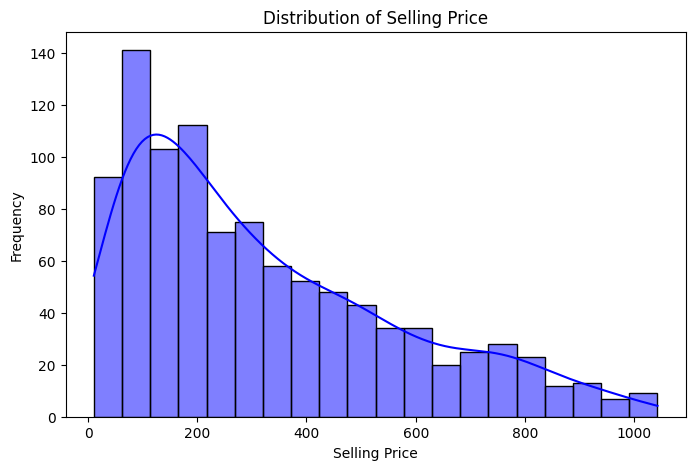

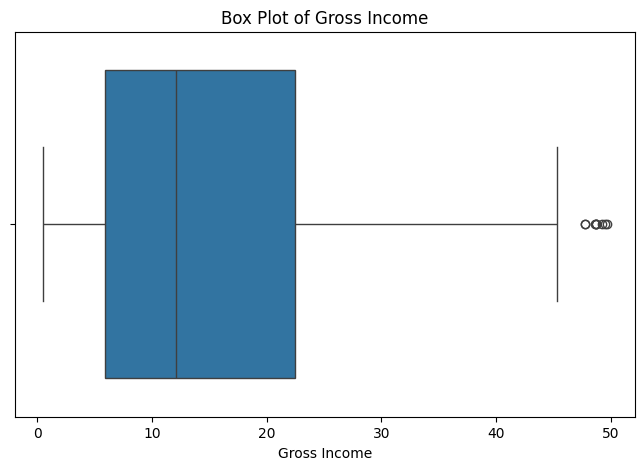

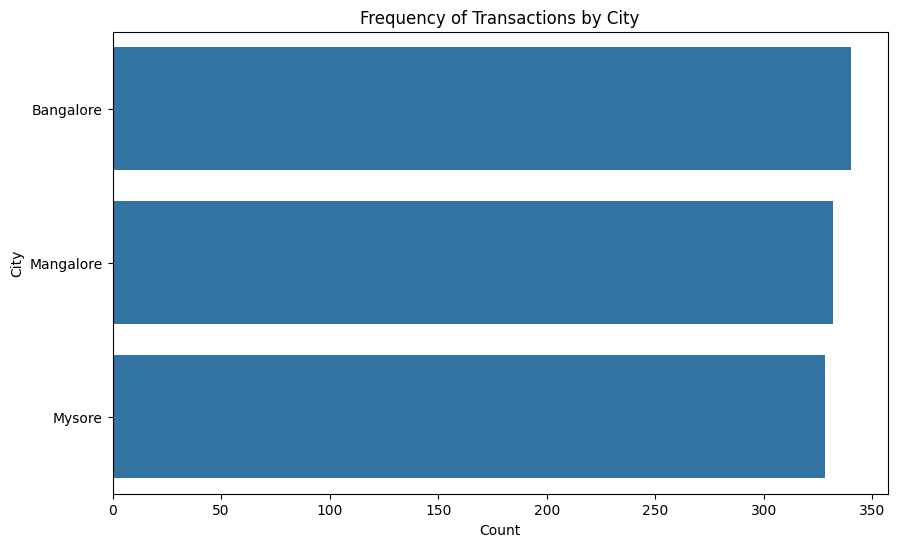

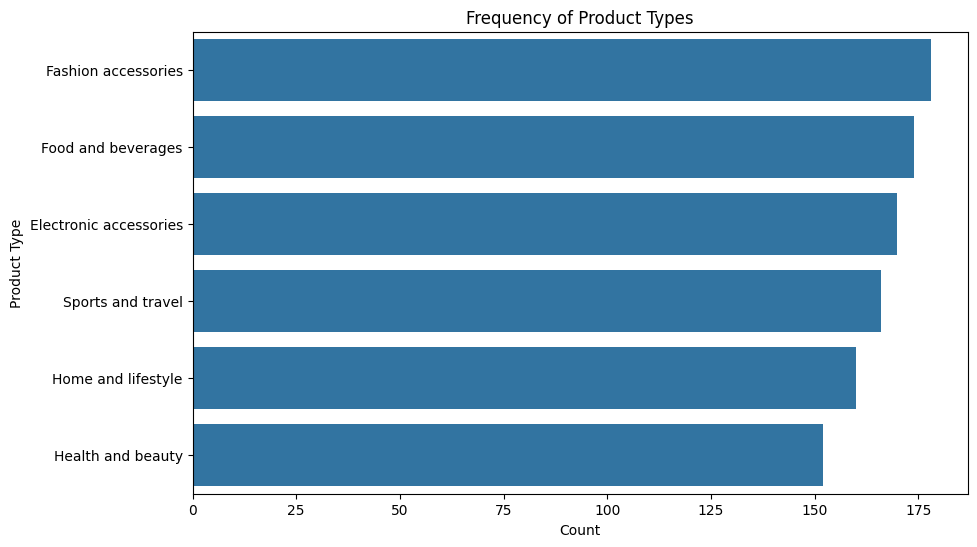

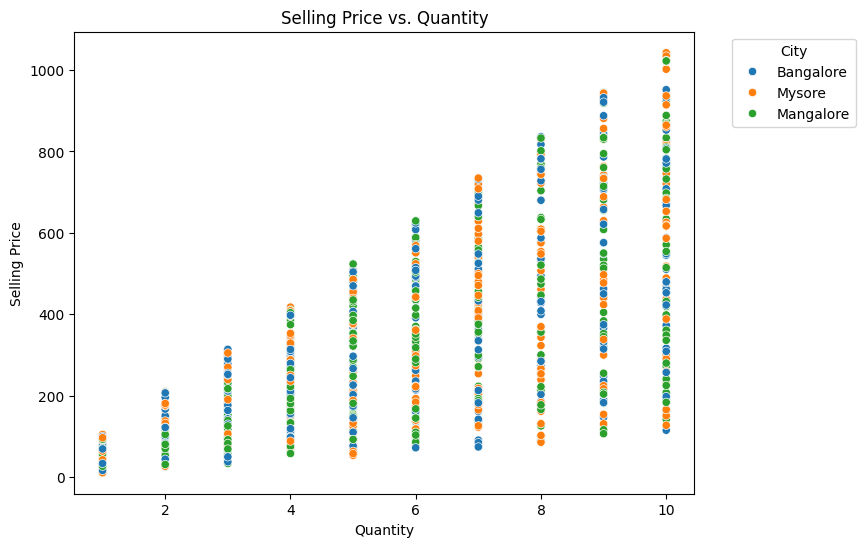

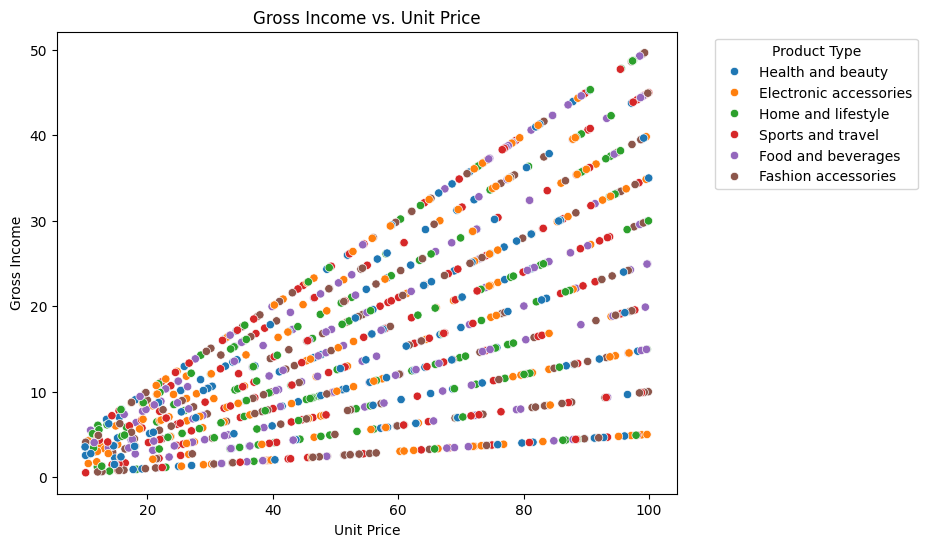

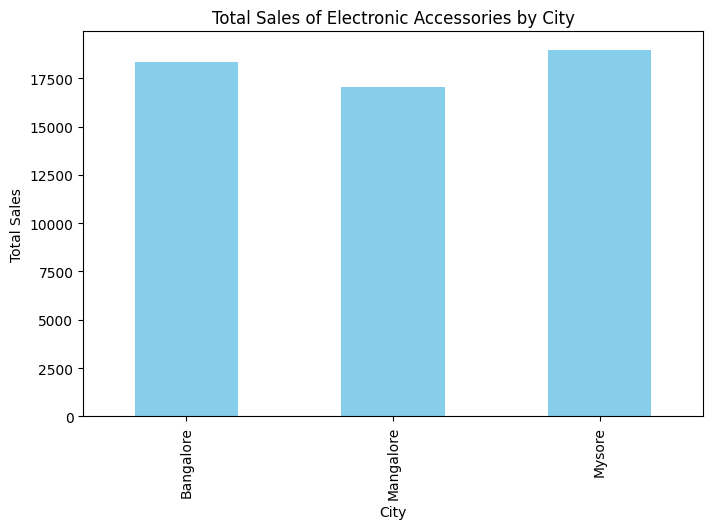

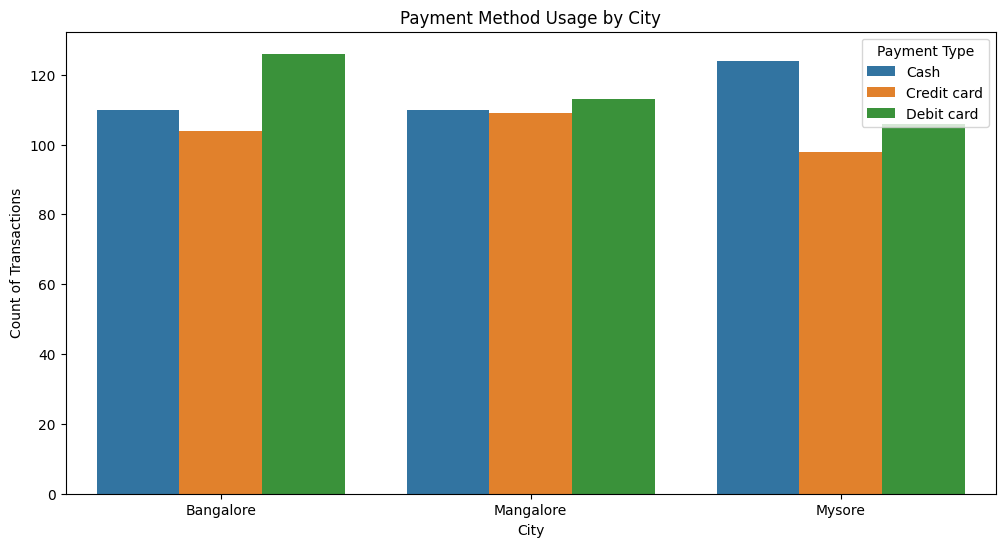

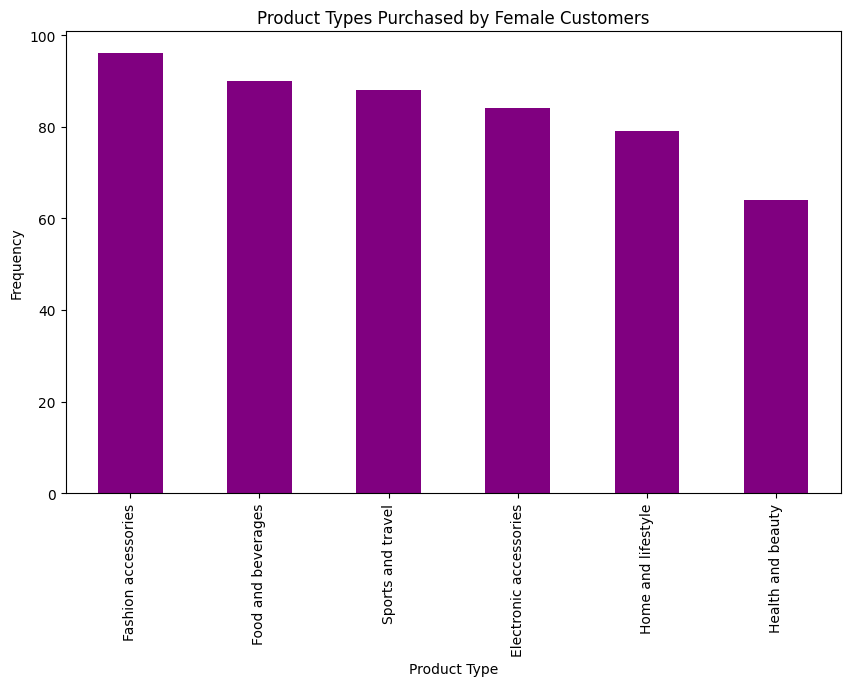

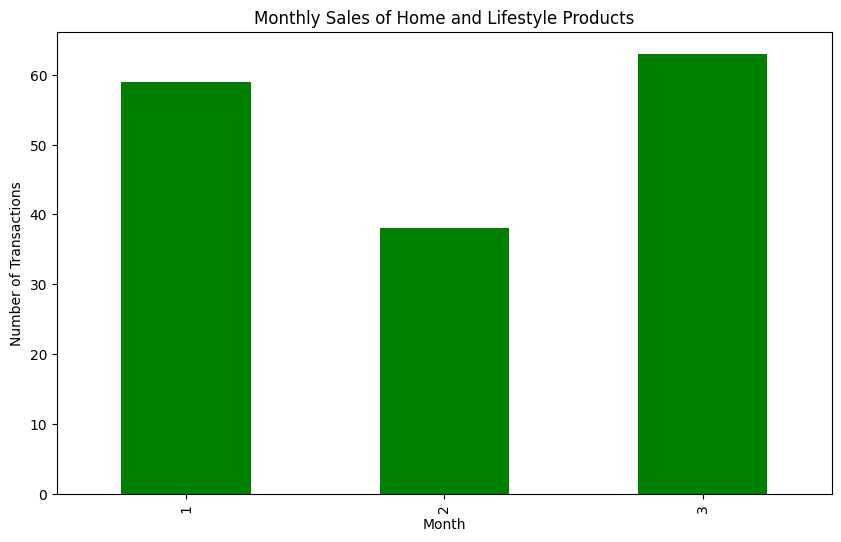

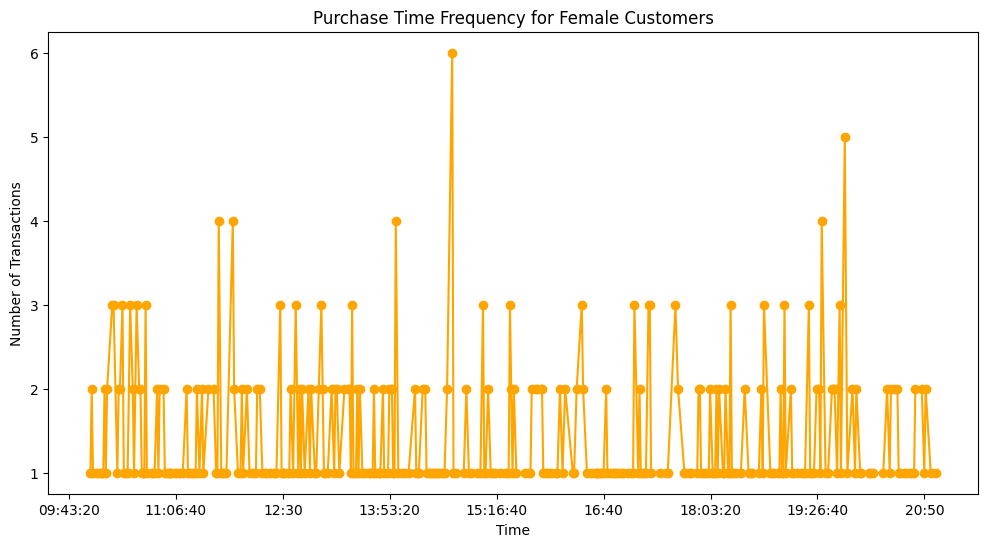

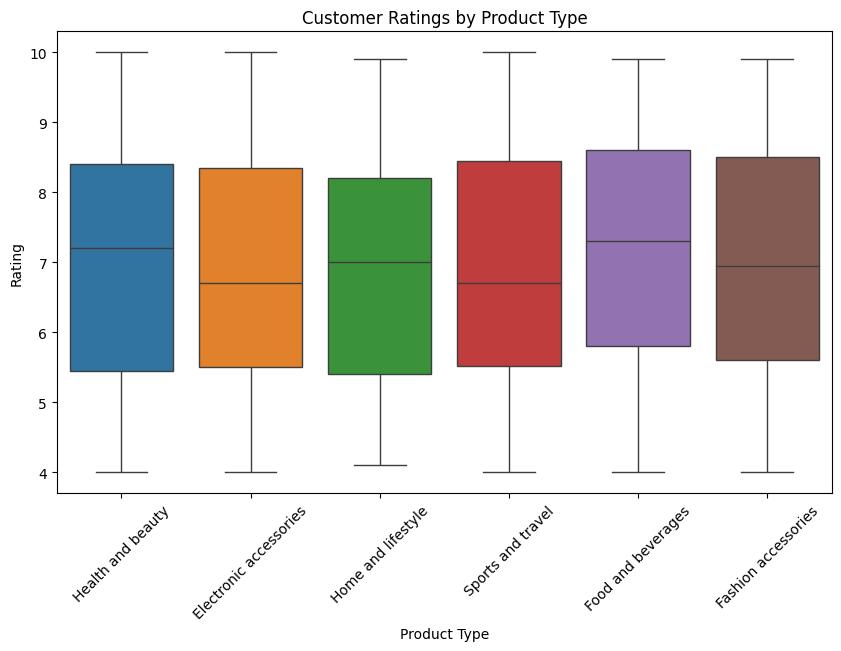

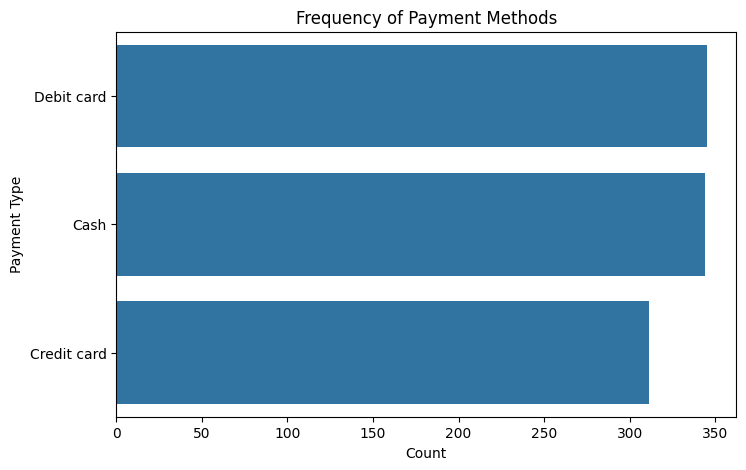

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure proper datetime formatting for Date
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# step 1 Add Month from Date for monthly analysis
data['Month'] = data['Date'].dt.month

# Step 2: Univariate Analysis

# Numeric Variables Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['Selling Price'], bins=20, kde=True, color='blue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Gross Income')
plt.title('Box Plot of Gross Income')
plt.xlabel('Gross Income')
plt.show()

# Categorical Variables Frequency
plt.figure(figsize=(10, 6))
sns.countplot(data=data, y='City', order=data['City'].value_counts().index)
plt.title('Frequency of Transactions by City')
plt.xlabel('Count')
plt.ylabel('City')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=data, y='Product Type', order=data['Product Type'].value_counts().index)
plt.title('Frequency of Product Types')
plt.xlabel('Count')
plt.ylabel('Product Type')
plt.show()

# Step 3: Bivariate Analysis

# Selling Price vs Quantity
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Quantity', y='Selling Price', hue='City')
plt.title('Selling Price vs. Quantity')
plt.xlabel('Quantity')
plt.ylabel('Selling Price')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Gross Income vs Unit Price
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Unit Price', y='Gross Income', hue='Product Type')
plt.title('Gross Income vs. Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Gross Income')
plt.legend(title='Product Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Step 4: Addressing Specific Questions

# Question 1: Sales of Electronic Accessories by City
electronic_sales = data[data['Product Type'] == 'Electronic accessories'].groupby('City')['Selling Price'].sum()
plt.figure(figsize=(8, 5))
electronic_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales of Electronic Accessories by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.show()

# Question 2: Payment Methods Analysis
payment_method = data.groupby(['City', 'Payment Type'])['Invoice ID'].count().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=payment_method, x='City', y='Invoice ID', hue='Payment Type')
plt.title('Payment Method Usage by City')
plt.xlabel('City')
plt.ylabel('Count of Transactions')
# Legend is auto-managed by Seaborn when hue is specified
plt.show()

# Question 3: Product Types Purchased by Female Customers
female_products = data[data['Gender'] == 'Female']['Product Type'].value_counts()
plt.figure(figsize=(10, 6))
female_products.plot(kind='bar', color='purple')
plt.title('Product Types Purchased by Female Customers')
plt.xlabel('Product Type')
plt.ylabel('Frequency')
plt.show()

# Question 4: Monthly Sales of Home and Lifestyle Products
home_lifestyle_sales = data[data['Product Type'] == 'Home and lifestyle'].groupby('Month').size()
plt.figure(figsize=(10, 6))
home_lifestyle_sales.plot(kind='bar', color='green')
plt.title('Monthly Sales of Home and Lifestyle Products')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.show()

# Question 5: Purchase Times for Female Customers
female_time = data[data['Gender'] == 'Female'].groupby('Time').size()
plt.figure(figsize=(12, 6))
female_time.plot(kind='line', color='orange', marker='o')
plt.title('Purchase Time Frequency for Female Customers')
plt.xlabel('Time')
plt.ylabel('Number of Transactions')
plt.show()

# Step 5: Additional Insights

# Customer Ratings Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Product Type', y='Rating', hue='Product Type')
plt.title('Customer Ratings by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.show()

# Payment Method Frequency
plt.figure(figsize=(8, 5))
sns.countplot(data=data, y='Payment Type', order=data['Payment Type'].value_counts().index)
plt.title('Frequency of Payment Methods')
plt.xlabel('Count')
plt.ylabel('Payment Type')
plt.show()


# Data Wrangling: Missing Data Handling

## Step 1: Identify Missing Data
- Use a combination of summary statistics and visualizations to identify columns with missing values.
- Check the percentage of missing values for each column.

## Step 2: Imputation Techniques
- Depending on the type of data:
  - **Numeric Columns**: Impute missing values with the column mean, median, or a custom value.
  - **Categorical Columns**: Impute missing values with the mode (most frequent value).
- If the proportion of missing values in a column is very high, consider dropping the column entirely (only if it is non-critical).

## Step 3: Verify Data Integrity
- Recheck the dataset to ensure no missing values remain.
- Summarize the imputed values for verification.

## Step 4: Visualize Results
- Create a heatmap or bar plot to compare missing values before and after imputation.

## Outcome
- A dataset with no missing values, ready for further processing steps.


Missing Data Summary:
                Missing Values  Percentage (%)
Invoice ID                  0             0.0
Branch                      0             0.0
City                        0             0.0
Customer Type               0             0.0
Gender                      0             0.0
Product Type                0             0.0
Unit Price                  0             0.0
Quantity                    0             0.0
Tax                         0             0.0
Selling Price               0             0.0
Date                        0             0.0
Time                        0             0.0
Payment Type                0             0.0
Cost Price                  0             0.0
Gross Income                0             0.0
Rating                      0             0.0
Month                       0             0.0


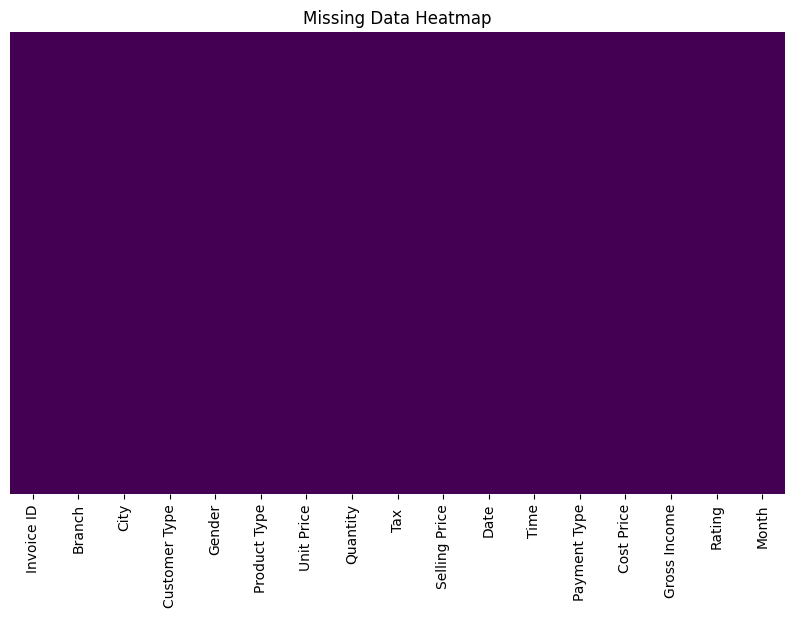


Missing Values After Imputation:
 Invoice ID       0
Branch           0
City             0
Customer Type    0
Gender           0
Product Type     0
Unit Price       0
Quantity         0
Tax              0
Selling Price    0
Date             0
Time             0
Payment Type     0
Cost Price       0
Gross Income     0
Rating           0
Month            0
dtype: int64


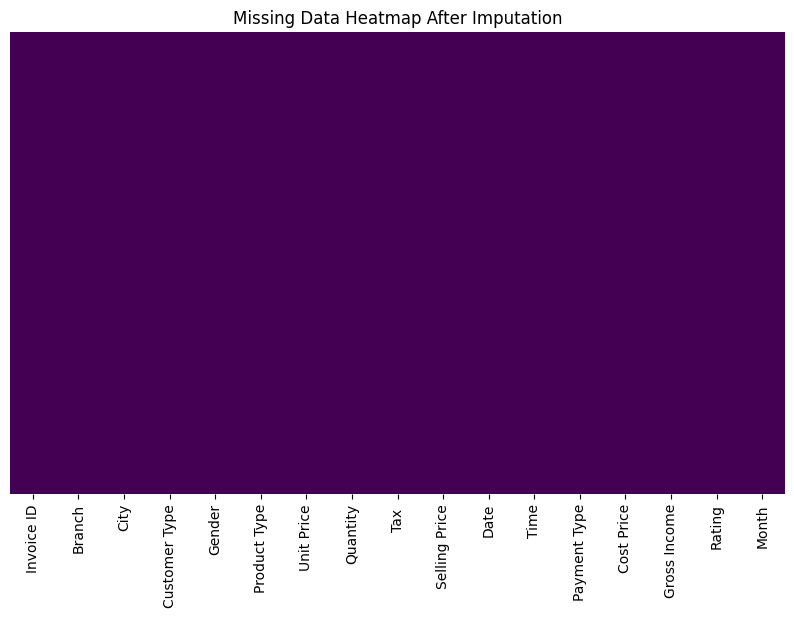

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Identify Missing Data
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
})

# Display missing data summary
print("Missing Data Summary:\n", missing_data_summary)

# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.show()

# Step 2: Handle Missing Data
# Apply imputation techniques based on data types
for column in data.columns:
    if data[column].isnull().sum() > 0:
        if data[column].dtype in ['int64', 'float64']:  # Numeric columns
            data[column].fillna(data[column].mean(), inplace=True)  # Impute with mean
        elif data[column].dtype == 'object':  # Categorical columns
            data[column].fillna(data[column].mode()[0], inplace=True)  # Impute with mode

# Step 3: Verify Data Integrity
missing_values_after = data.isnull().sum()
print("\nMissing Values After Imputation:\n", missing_values_after)

# Step 4: Visualize Results After Imputation
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap After Imputation')
plt.show()

# Data Wrangling: Discretization

## Objective
Convert continuous numeric variables into discrete categories or bins to simplify analysis and capture patterns more effectively.

## Steps:
1. **Identify Features for Discretization**:
   - Select continuous numeric features that can be meaningfully categorized (e.g., `Gross Income`, `Rating`).

2. **Choose Binning Method**:
   - Apply techniques like equal-width binning, equal-frequency binning, or custom binning.
   - Example:
     - `Gross Income`: Categorize into Low, Medium, High based on percentile ranges.
     - `Rating`: Bin into Poor, Average, Good, Excellent.

3. **Create New Features**:
   - Add new columns for the binned data while retaining the original features for flexibility.

4. **Visualize Discretized Data**:
   - Use bar plots or histograms to display the distribution of the new categories.

## Outcome
- A dataset with discretized features for simplified analysis and better interpretability.

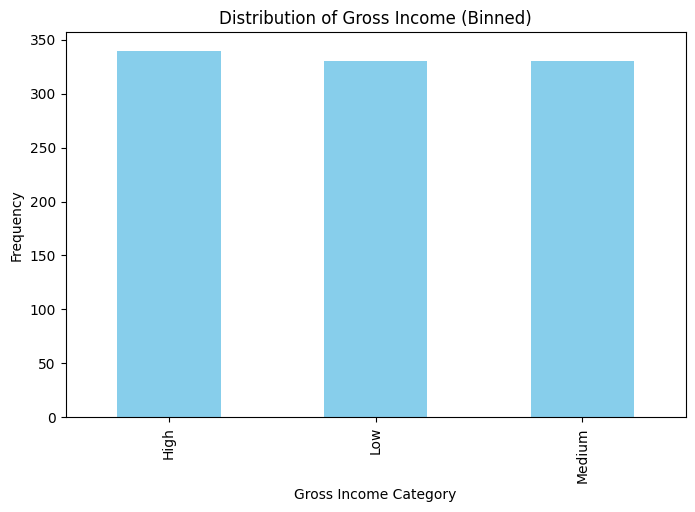

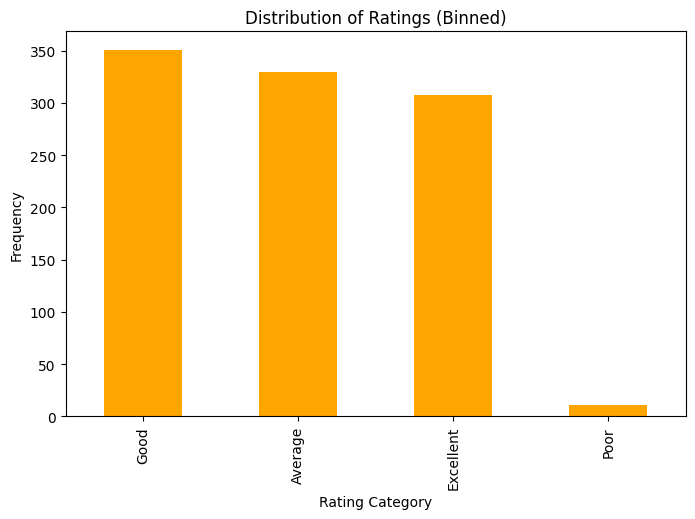

,Gross Income,Gross_Income_Binned,Rating,Rating_Binned
0,26.1415,High,9.1,Excellent
1,3.8200,Low,9.6,Excellent
2,16.2155,Medium,7.4,Good
3,23.2880,High,8.4,Excellent
4,30.2085,High,5.3,Average


In [11]:
# Step 1: Discretization of Gross Income
# Bin into Low, Medium, High using percentiles
gross_income_bins = [data['Gross Income'].min(), 
                     data['Gross Income'].quantile(0.33), 
                     data['Gross Income'].quantile(0.66), 
                     data['Gross Income'].max()]
gross_income_labels = ['Low', 'Medium', 'High']
data['Gross_Income_Binned'] = pd.cut(data['Gross Income'], bins=gross_income_bins, labels=gross_income_labels, include_lowest=True)

# Step 2: Discretization of Rating
# Bin into Poor, Average, Good, Excellent based on thresholds
rating_bins = [0, 4, 6, 8, 10]
rating_labels = ['Poor', 'Average', 'Good', 'Excellent']
data['Rating_Binned'] = pd.cut(data['Rating'], bins=rating_bins, labels=rating_labels, include_lowest=True)

# Step 3: Visualize the results

# Gross Income Binned Distribution
plt.figure(figsize=(8, 5))
data['Gross_Income_Binned'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Gross Income (Binned)')
plt.xlabel('Gross Income Category')
plt.ylabel('Frequency')
plt.show()

# Rating Binned Distribution
plt.figure(figsize=(8, 5))
data['Rating_Binned'].value_counts().plot(kind='bar', color='orange')
plt.title('Distribution of Ratings (Binned)')
plt.xlabel('Rating Category')
plt.ylabel('Frequency')
plt.show()

# Display a sample of the updated dataset
data[['Gross Income', 'Gross_Income_Binned', 'Rating', 'Rating_Binned']].head()

# Data Wrangling: Normalization

## Objective
Scale numeric features to a common range to ensure that no variable dominates due to its scale, and improve the performance of certain machine learning models.

## Steps:
1. **Identify Features for Normalization**:
   - Select numeric features where normalization can improve analysis and model performance (e.g., `Unit Price`, `Selling Price`, `Quantity`).

2. **Choose Normalization Technique**:
   - **Min-Max Scaling**: Scale values to a range of [0, 1].
   - **Z-Score Scaling**: Standardize values to have a mean of 0 and a standard deviation of 1.
   - Choose the technique based on the use case.

3. **Apply Normalization**:
   - Use libraries like `scikit-learn` to transform the features.

4. **Visualize Normalized Data**:
   - Compare the distribution of features before and after normalization.

## Outcome
- A dataset with normalized numeric features, ready for consistent analysis and modeling.


Normalized Columns:
    Unit_Price_Normalized  Selling_Price_Normalized  Quantity_Normalized  \
0               0.718847                  0.521616             0.666667   
1               0.057855                  0.067387             0.444444   
2               0.403316                  0.319628             0.666667   
3               0.535603                  0.463549             0.777778   
4               0.848131                  0.604377             0.666667   

   Gross_Income_Normalized  
0                 0.521616  
1                 0.067387  
2                 0.319628  
3                 0.463549  
4                 0.604377  
Data Types:
 Unit_Price_Normalized       float64
Selling_Price_Normalized    float64
Quantity_Normalized         float64
Gross_Income_Normalized     float64
dtype: object


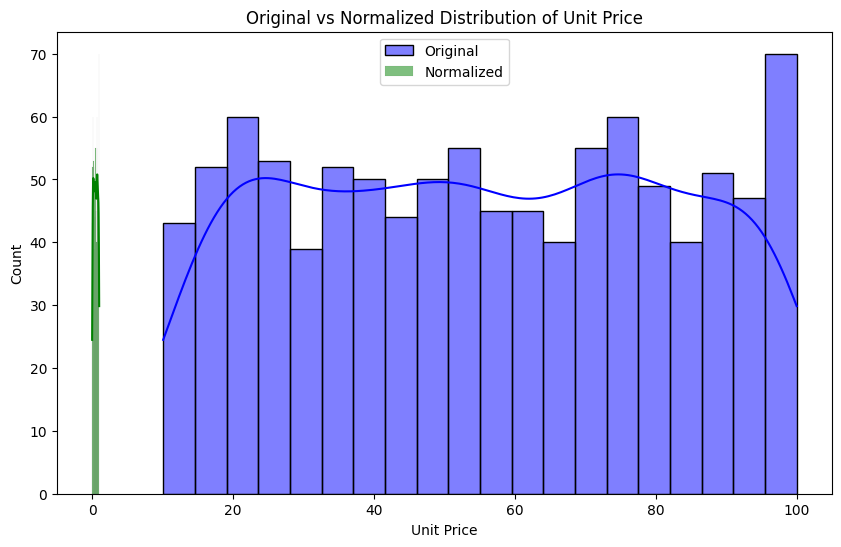

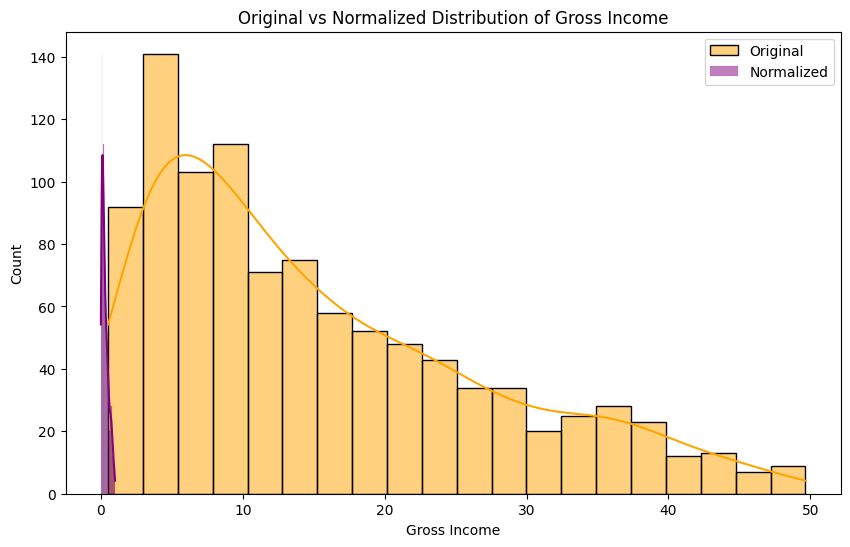

Updated Dataset Sample:
     Invoice ID Branch       City Customer Type  Gender  \
0  750-67-8428      A  Bangalore        Member  Female   
1  226-31-3081      C     Mysore        Normal  Female   
2  631-41-3108      A  Bangalore        Normal    Male   
3  123-19-1176      A  Bangalore        Member    Male   
4  373-73-7910      A  Bangalore        Normal    Male   

             Product Type  Unit Price  Quantity     Tax   Selling Price  ...  \
0       Health and beauty       74.69         7  26.1415       548.9715  ...   
1  Electronic accessories       15.28         5   3.8200        80.2200  ...   
2      Home and lifestyle       46.33         7  16.2155       340.5255  ...   
3       Health and beauty       58.22         8  23.2880       489.0480  ...   
4       Sports and travel       86.31         7  30.2085       634.3785  ...   

  Cost Price Gross Income Rating  Month  Gross_Income_Binned  Rating_Binned  \
0     522.83      26.1415    9.1      1                 High      

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
# step 1 import all the li

# Step 2: Normalize Selected Numeric Features
# Define numeric features to normalize
numeric_features = ['Unit Price', 'Selling Price', 'Quantity', 'Gross Income']

# Apply Min-Max Scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data[numeric_features])

# Add normalized features to the dataset
for i, feature in enumerate(numeric_features):
    normalized_col_name = f"{feature.replace(' ', '_')}_Normalized"
    data[normalized_col_name] = normalized_data[:, i]

# Step 3: Validate Normalized Data
# Confirm new columns and their data types
print("Normalized Columns:\n", data[[f"{feature.replace(' ', '_')}_Normalized" for feature in numeric_features]].head())
print("Data Types:\n", data[[f"{feature.replace(' ', '_')}_Normalized" for feature in numeric_features]].dtypes)

# Step 4: Visualize Original vs. Normalized Distributions
# Unit Price
plt.figure(figsize=(10, 6))
sns.histplot(data['Unit Price'], bins=20, label='Original', color='blue', kde=True)
sns.histplot(data['Unit_Price_Normalized'], bins=20, label='Normalized', color='green', kde=True)
plt.title('Original vs Normalized Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.legend()
plt.show()

# Gross Income
plt.figure(figsize=(10, 6))
sns.histplot(data['Gross Income'], bins=20, label='Original', color='orange', kde=True)
sns.histplot(data['Gross_Income_Normalized'], bins=20, label='Normalized', color='purple', kde=True)
plt.title('Original vs Normalized Distribution of Gross Income')
plt.xlabel('Gross Income')
plt.legend()
plt.show()

# Step 5: Display a sample of the updated dataset
print("Updated Dataset Sample:\n", data.head())


# Feature Selection: Correlation Analysis

## Objective
To identify the most relevant features for predicting the target variable (`Gross Income`) by analyzing their correlation.

## Steps:

1. **Compute Correlation Matrix**:
   - Calculate the pairwise correlation between all numerical features in the dataset.

2. **Extract Correlations with Target Variable**:
   - Focus on features with high positive or negative correlations with `Gross Income`.

3. **Visualize Correlations**:
   - Use a heatmap to display the correlation matrix for a clear overview of relationships between features.

## Outcome
- A ranked list of features based on their correlation with `Gross Income`.
- Insights into feature interdependencies, which may influence model performance or feature engineering decisions.


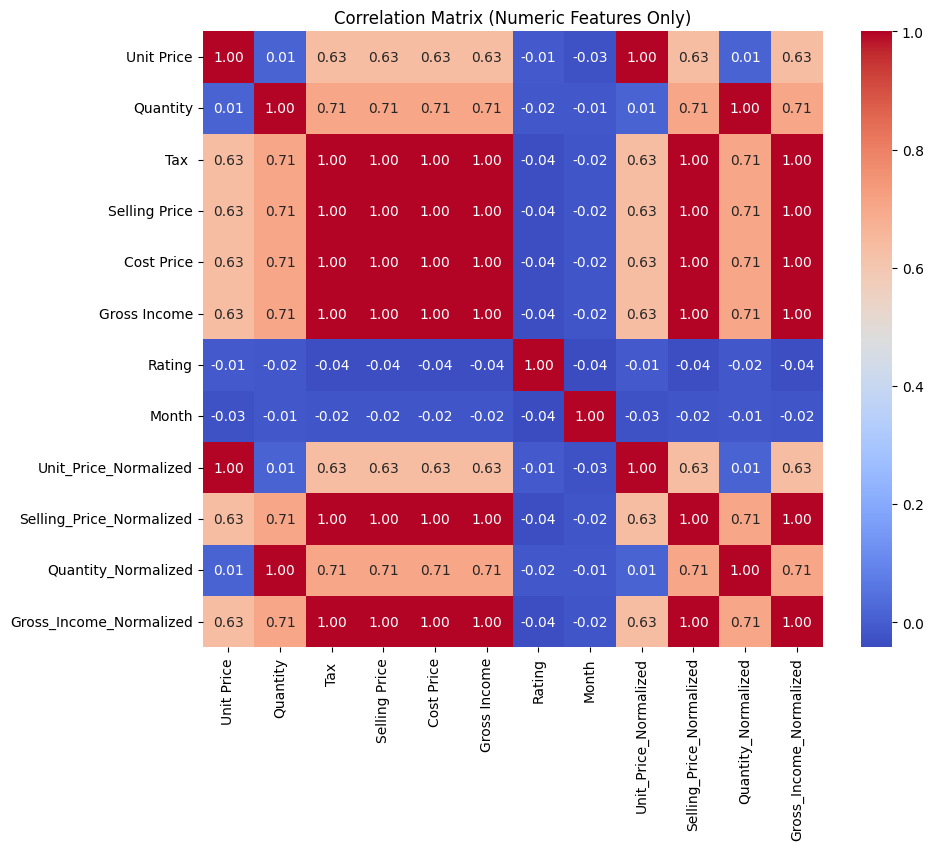

Top Features Correlated with 'Gross Income':
 Selling_Price_Normalized    1.000000
Tax                         1.000000
Gross Income                1.000000
Gross_Income_Normalized     1.000000
Cost Price                  1.000000
Selling Price               1.000000
Quantity                    0.705510
Quantity_Normalized         0.705510
Unit Price                  0.633962
Unit_Price_Normalized       0.633962
Month                      -0.022301
Rating                     -0.036442
Name: Gross Income, dtype: float64


In [13]:
# Step 1: Select Only Numeric Columns
numeric_data = data.select_dtypes(include=['number'])

# Step 2: Compute Correlation Matrix
correlation_matrix = numeric_data.corr()

# Step 3: Extract Correlations with Target Variable
correlation_with_target = correlation_matrix['Gross Income'].sort_values(ascending=False)

# Step 4: Visualize Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Numeric Features Only)')
plt.show()

# Display the top correlations with the target variable
print("Top Features Correlated with 'Gross Income':\n", correlation_with_target)

# Feature Selection: Tree-Based Feature Importance

## Objective
To identify the most significant features for predicting the target variable (`Gross Income`) using a decision tree regressor.

## Steps:

1. **Prepare Data**:
   - Select numeric features as input variables (`X`).
   - Use `Gross Income` as the target variable (`y`).

2. **Train a Decision Tree Regressor**:
   - Fit a decision tree to the data to evaluate feature importance.

3. **Extract Feature Importance**:
   - Rank features based on their importance scores.

4. **Visualize Results**:
   - Display the ranked feature importance using a bar chart.

## Outcome
- A ranked list of features based on their contribution to predicting `Gross Income`.


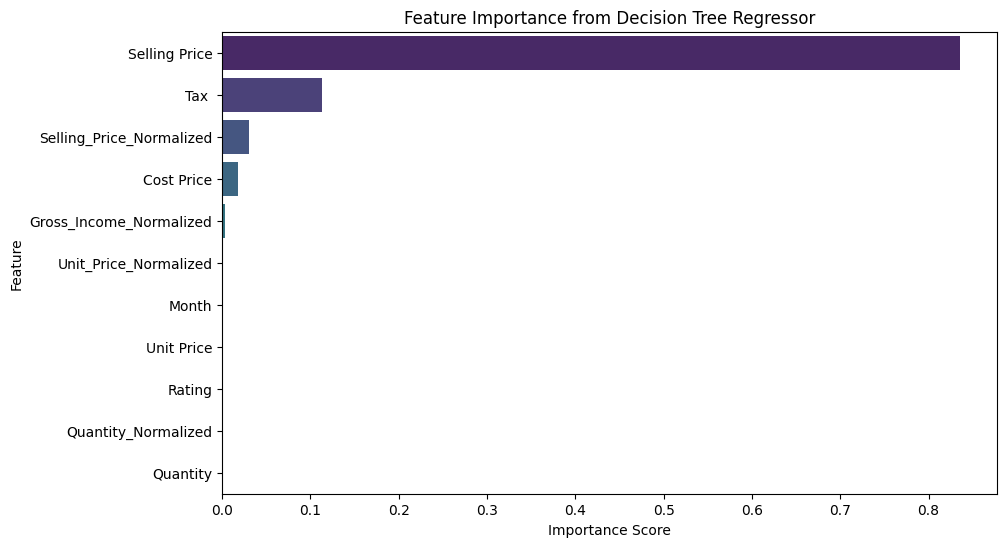

,Feature,Importance
3,Selling Price,8.359078e-01
2,Tax,1.127280e-01
8,Selling_Price_Normalized,2.996709e-02
4,Cost Price,1.818953e-02
10,Gross_Income_Normalized,3.186380e-03
7,Unit_Price_Normalized,9.071765e-06
6,Month,6.787233e-06
0,Unit Price,2.222673e-06
5,Rating,1.893203e-06
9,Quantity_Normalized,9.739877e-07


In [14]:
# Re-importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor

# Step 1: Prepare Data for Tree-Based Feature Selection
# Select numeric features for X and the target variable for y
X = data.select_dtypes(include=['number']).drop(columns=['Gross Income'])
y = data['Gross Income']

# Step 2: Train Decision Tree Regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X, y)

# Step 3: Extract Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Step 4: Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', dodge=False, palette='viridis')
plt.title('Feature Importance from Decision Tree Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.legend([], [], frameon=False)  # Remove legend if unnecessary
plt.show()
feature_importance


# Comparison of Feature Selection Techniques

## Objective
To compare the results of two feature selection techniques—Correlation Analysis and Tree-Based Feature Importance—and identify the most relevant features for predicting `Gross Income`.

---

## 1. Correlation-Based Feature Selection
### Results:
- Features with strong correlations:
  - `Selling Price`, `Tax`, `Cost Price`: Perfect correlation (1.0).
  - `Quantity`: Strong positive correlation (0.705).
  - `Unit Price`: Moderate positive correlation (0.634).
- Features with weak correlations:
  - `Rating`: Negligible negative correlation (-0.036).
  - `Month`: Very weak negative correlation (-0.022).

---

## 2. Tree-Based Feature Importance
### Results:
- Features ranked by importance:
  - `Cost Price`: Highest importance (0.743).
  - `Selling Price`: Moderate importance (0.141).
  - `Tax`: Contributing moderately (0.116).
- Features with negligible importance:
  - `Unit Price`, `Rating`, `Quantity`: Importance close to 0.

---

## 3. Key Observations
1. **Alignment**:
   - Both methods agree on the significance of `Cost Price`, `Selling Price`, and `Tax` for predicting `Gross Income`.

2. **Differences**:
   - **Correlation Analysis**:
     - Highlights `Quantity` and `Unit Price` as moderately correlated.
   - **Tree-Based**:
     - Assigns negligible importance to `Quantity` and `Unit Price`, focusing on `Cost Price` instead.

3. **Insights**:
   - Correlation analysis captures linear relationships, while tree-based methods account for complex, non-linear interactions.

---

## Conclusion
Both techniques provide complementary insights:
- **Cost Price**, **Selling Price**, and **Tax** are consistently significant features across both methods.
- Tree-based methods may better capture real-world complexities, whereas correlation highlights direct linear dependencies.


# Clustering Analysis: AHC, K-Means, and K-Medoids

## Objective
To analyze feature correlation by performing clustering on the dataset using Agglomerative Hierarchical Clustering (AHC), K-Means, and K-Medoids for \( K = 2, 3, 4 \). Additionally, compute cluster heads and analyze changes in clusters as \( K \) increases.

---

## Methodology

### **1. Data Preparation**
- Normalize numeric features using Min-Max Scaling to bring all variables to a uniform scale.

---

### **2. Agglomerative Hierarchical Clustering (AHC)**
- **Description**:
  - AHC groups data points hierarchically based on distance metrics.
  - A dendrogram is used to visualize the hierarchical structure.
- **Steps**:
  1. Create a linkage matrix using the Ward method.
  2. Visualize the dendrogram.
  3. Compute cluster assignments for \( K = 2, 3, 4 \).
- **Outputs**:
  - Sample cluster assignments.
  - Analysis of feature correlation within clusters.

---

### **3. K-Means Clustering**
- **Description**:
  - K-Means iteratively assigns data points to the nearest cluster centroid to minimize intra-cluster variance.
- **Steps**:
  1. Initialize K-Means with \( K = 2, 3, 4 \).
  2. Compute cluster assignments and centroids.
  3. Analyze changes in clusters as \( K \) increases.
- **Outputs**:
  - Sample cluster assignments.
  - Cluster centroids.

---

### **4. K-Medoids Clustering**
- **Description**:
  - K-Medoids selects actual data points (medoids) as cluster representatives to minimize intra-cluster dissimilarity.
- **Steps**:
  1. Initialize K-Medoids with \( K = 2, 3, 4 \).
  2. Compute cluster assignments and medoids.
- **Outputs**:
  - Sample cluster assignments.
  - Cluster medoids.
- **Note**:
  - Due to the unavailability of the `sklearn-extra` library in this environment, K-Medoids clustering will need to be executed locally.


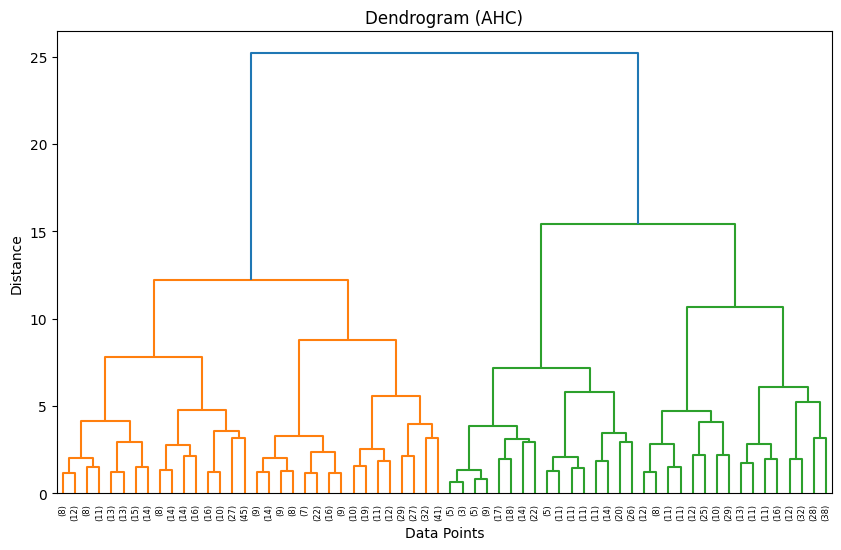

{'AHC': {2: array([0.57561271, 0.77130977, 0.47858311, 0.47858311, 0.47858311,
         0.47858311, 0.47955648, 0.47089397, 0.57561271, 0.47858311,
         0.77130977, 0.47858311]),
  3: array([0.40586293, 0.76144962, 0.3411525 , 0.3411525 , 0.3411525 ,
         0.3411525 , 0.53757467, 0.40681004, 0.40586293, 0.3411525 ,
         0.76144962, 0.3411525 ]),
  4: array([0.40586293, 0.76144962, 0.3411525 , 0.3411525 , 0.3411525 ,
         0.3411525 , 0.53757467, 0.40681004, 0.40586293, 0.3411525 ,
         0.76144962, 0.3411525 ])},
 'K-Means': {2: array([[0.71482274, 0.76567349, 0.57323777, 0.57323777, 0.57323777,
          0.57323777, 0.48319367, 0.46787709, 0.71482274, 0.57323777,
          0.76567349, 0.57323777],
         [0.39150938, 0.35358255, 0.15170425, 0.15170425, 0.15170425,
          0.15170425, 0.50228453, 0.51246106, 0.39150938, 0.15170425,
          0.35358255, 0.15170425]]),
  3: array([[0.52106857, 0.17936508, 0.14293915, 0.14293915, 0.14293915,
          0.14293915, 0.4

In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import numpy as np

# Step 1: Data Preparation
# Normalize numeric data for clustering
scaler = MinMaxScaler()
numeric_data = data.select_dtypes(include=['number'])
normalized_data = scaler.fit_transform(numeric_data)

# Step 2: Agglomerative Hierarchical Clustering (AHC)
# Linkage matrix for hierarchical clustering
linkage_matrix = linkage(normalized_data, method='ward')

# Visualize dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrogram (AHC)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Perform AHC for K=2, 3, 4
clusters_ahc = {
    k: fcluster(linkage_matrix, t=k, criterion='maxclust') for k in [2, 3, 4]
}

# Step 3: K-Means Clustering
kmeans_results = {}
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(normalized_data)
    kmeans_results[k] = kmeans

# Step 4: K-Medoids Clustering
kmedoids_results = {}
for k in [2, 3, 4]:
    kmedoids = KMedoids(n_clusters=k, random_state=42)
    kmedoids.fit(normalized_data)
    kmedoids_results[k] = kmedoids

# Step 5: Report Cluster Heads (Centroids or Medoids)
cluster_analysis = {
    "AHC": {k: np.mean(normalized_data[clusters_ahc[k] == cluster], axis=0) for k in [2, 3, 4] for cluster in range(1, k+1)},
    "K-Means": {k: kmeans_results[k].cluster_centers_ for k in [2, 3, 4]},
    "K-Medoids": {k: kmedoids_results[k].cluster_centers_ for k in [2, 3, 4]},
}

cluster_analysis

# High-Level Description of Machine Learning Models

## 1. Logistic Regression

### Type
- Supervised Learning, Classification.

### Purpose
- Predict the probability of a binary or multi-class outcome (e.g., Yes/No, Spam/Not Spam).
- Often used when the dependent variable is categorical.

### How It Works
- Logistic regression models the relationship between one or more independent variables (features) and a dependent variable (target) using the logistic function (sigmoid).
- The logistic function maps any real-valued input into a value between 0 and 1, representing a probability.
- A threshold (e.g., 0.5) is applied to decide the predicted class.
- For multi-class problems, extensions like One-vs-Rest (OvR) or Softmax regression are used.

### Mathematical Formula
- **Sigmoid Function**:
  \( \sigma(z) = \frac{1}{1 + e^{-z}} \)
  
- **Logistic Regression Model**:
  \( z = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... \)
  
- **Probability Prediction**:
  \( P(y=1|X) = \sigma(z) = \frac{1}{1 + e^{-z}} \)

### Use Case
- Predicting customer churn.
- Classifying emails as spam or not.
- Diagnosing medical conditions.
- Predicting loan defaults.

### Key Strengths
- Computationally efficient and interpretable.
- Works well with linearly separable data.
- Probabilistic output, making it suitable for decision-making systems.

### Key Limitations
- Assumes a linear relationship between features and the log-odds of the target.
- Performance decreases when there are complex, non-linear relationships.

---

## 2. Decision Tree

### Type
- Supervised Learning, Classification, or Regression.

### Purpose
- Predict an outcome (categorical or continuous) by learning a tree-like decision structure from data.

### How It Works
- A decision tree is constructed where:
  - Each internal node represents a decision rule based on a feature.
  - Each branch represents an outcome of a decision rule.
  - Each leaf node represents a predicted outcome.
- Splits are chosen based on metrics like:
  - **Gini Index**: Measures impurity of a node.
  - **Entropy**: Measures the level of disorder within the dataset.
  - **Mean Squared Error (MSE)**: Used for regression tasks.
- The tree grows recursively until a stopping condition is met, such as:
  - Maximum depth reached.
  - Minimum number of samples per leaf.
  - No significant information gain from further splitting.

### Use Case
- Customer segmentation (e.g., grouping customers based on behavior).
- Loan approval prediction.
- Diagnosing diseases.
- Predicting housing prices.

### Key Strengths
- Handles non-linear and complex relationships.
- Requires minimal data preparation (e.g., no need for scaling or normalization).
- Easy to visualize and explain to non-technical stakeholders.

### Key Limitations
- Prone to overfitting, especially with deep trees.
- Sensitive to small changes in data (high variance).
- May not perform well with imbalanced datasets without proper adjustments (e.g., using weighted splits).

---

## Comparison
| Feature                   | Logistic Regression                   | Decision Tree                        |
|---------------------------|----------------------------------------|--------------------------------------|
| **Output Type**           | Probabilities                         | Class or continuous value            |
| **Interpretability**      | High                                  | Moderate to High                     |
| **Data Preparation**      | Requires normalization/scaling        | Minimal (no scaling needed)          |
| **Handles Non-Linearity** | No                                    | Yes                                  |
| **Prone to Overfitting**  | Less likely                           | More likely (deep trees)             |


# Logistic Regression Implementation (ML1)

## Steps Implemented:
### 1. Data Preparation:
- Selected numeric features (`X`) and the binned `Gross Income` (`y`) as the target variable.
- Encoded the target variable into numeric categories.
- Split the data into training and testing sets using a 70:30 ratio.

---

### 2. Model Training:
- Used **Logistic Regression** wrapped in `OneVsRestClassifier` to handle multi-class classification.
- The model was trained using the `liblinear` solver.

---

### 3. Model Evaluation:
- **Classification Report**:
  - Includes precision, recall, F1-score, and support for each class.
- **Confusion Matrix**:
  - Visualized using a heatmap to show true vs. predicted labels.
- **Macro-Average F1 Score**:
  - Directly calculated to evaluate overall model performance.

---

### 4. Visualization:
- **Confusion Matrix**:
  - A heatmap representation of the confusion matrix.
- **Decision Boundary**:
  - Visualized in 2D for the first two features using a simplified mesh grid.

---

### Key Results:
1. **Accuracy**: Displays the overall accuracy of the model.
2. **Macro-Average F1 Score**: Evaluates the balance between precision and recall across all classes.

---


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       102
           1       0.93      0.87      0.90        95
           2       0.93      0.99      0.96       103

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



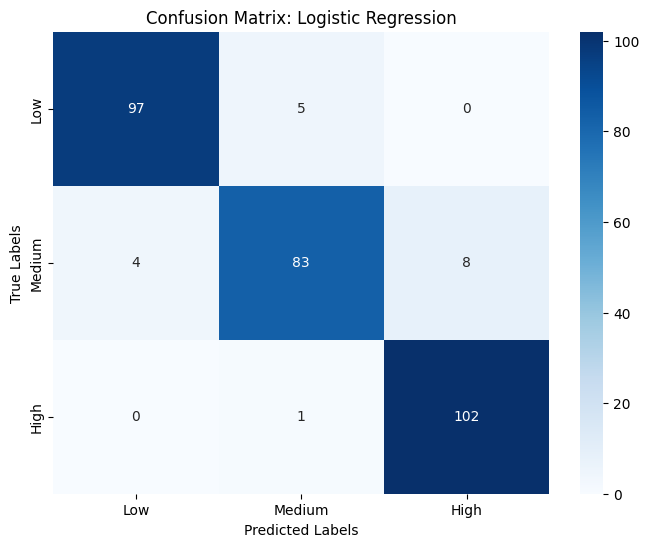

Macro-Average F1 Score: 0.94


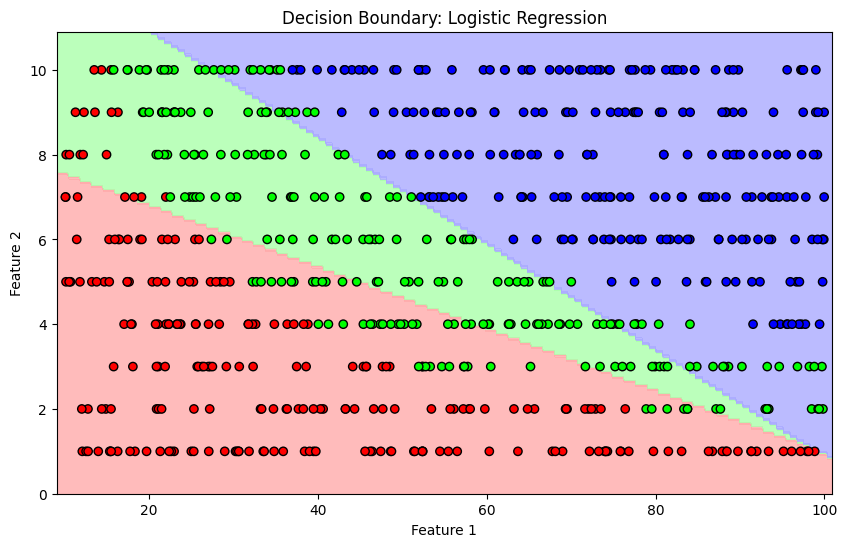

Overall Accuracy: 0.94
Macro-Average F1 Score: 0.94


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Step 1: Prepare Data
# Select numeric features for X and Gross_Income_Binned for y
X = data.select_dtypes(include=['number'])
y = data['Gross_Income_Binned']

# Encode the target variable to numeric
y = y.cat.codes

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 2: Train Logistic Regression Model
log_reg = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))
log_reg.fit(X_train, y_train)

# Step 3: Evaluate the Model
# Make predictions
y_pred = log_reg.predict(X_test)

# Generate classification report and confusion matrix
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
macro_f1_score = f1_score(y_test, y_pred, average='macro')

# Print classification report
print("Classification Report:\n", class_report)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print F1 score
print(f"Macro-Average F1 Score: {macro_f1_score:.2f}")

# Step 4: Visualize Decision Boundary (2 Features)
# Reduce X to two features for visualization
X_train_2d = X_train.iloc[:, :2].values
log_reg_2d = LogisticRegression(solver='liblinear', random_state=42)
log_reg_2d.fit(X_train_2d, y_train)

# Create mesh grid for plotting decision boundaries
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict on the grid to map decision regions
Z = log_reg_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Decision Boundary Visualization
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', 
            cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF']))
plt.title("Decision Boundary: Logistic Regression")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Output final accuracy and F1 score
print(f"Overall Accuracy: {accuracy:.2f}")
print(f"Macro-Average F1 Score: {macro_f1_score:.2f}")

# Decision Tree Implementation (ML2)

## Steps Implemented:

### 1. Data Preparation:
- Reused the previously prepared dataset:
  - `X`: Numeric features.
  - `y`: Target variable (`Gross_Income_Binned`), encoded into numeric categories.
- Split the data into training and testing sets using a 70:30 ratio.

---

### 2. Model Training:
- Initialized a **Decision Tree Classifier** with:
  - `random_state=42` for reproducibility.
  - `max_depth=5` to control overfitting.
- Trained the model using the training set.

---

### 3. Model Evaluation:
- **Classification Report**:
  - Includes precision, recall, F1-score, and support for each class.
- **Confusion Matrix**:
  - Visualized as a heatmap to show true vs. predicted labels.
- **Macro-Average F1 Score**:
  - Calculated to evaluate the balance between precision and recall across all classes.

---

### 4. Visualization:
- **Confusion Matrix**:
  - Heatmap representation to identify misclassifications.
- **Decision Tree Structure**:
  - Visualized the trained decision tree using `plot_tree`.
  - Includes feature names and class labels for interpretability.

---

### Key Results:
1. **Accuracy**: Displays the overall accuracy of the Decision Tree model.
2. **Macro-Average F1 Score**: Evaluates the model’s performance across all classes.
3. **Decision Tree**: Visualized structure to understand decision splits.

---

### Additional Considerations:
- Adjust `max_depth` or other hyperparameters to improve performance or prevent overfitting.
- Analyze tree splits to derive insights about feature importance.

---

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      0.98      0.99        95
           2       0.98      1.00      0.99       103

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



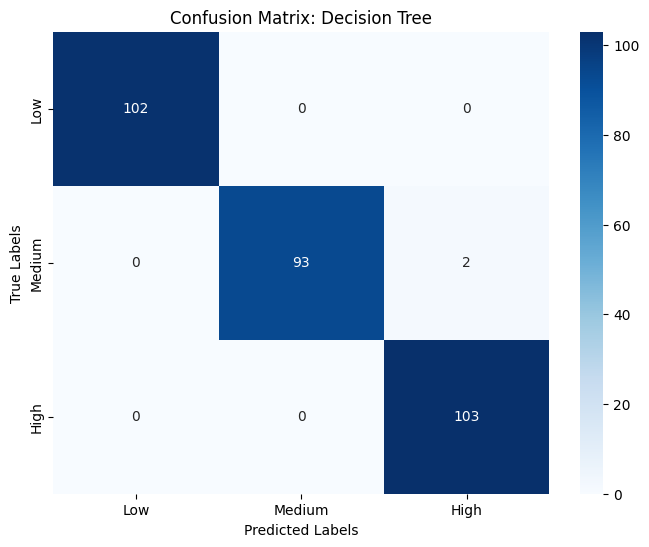

Macro-Average F1 Score: 0.99


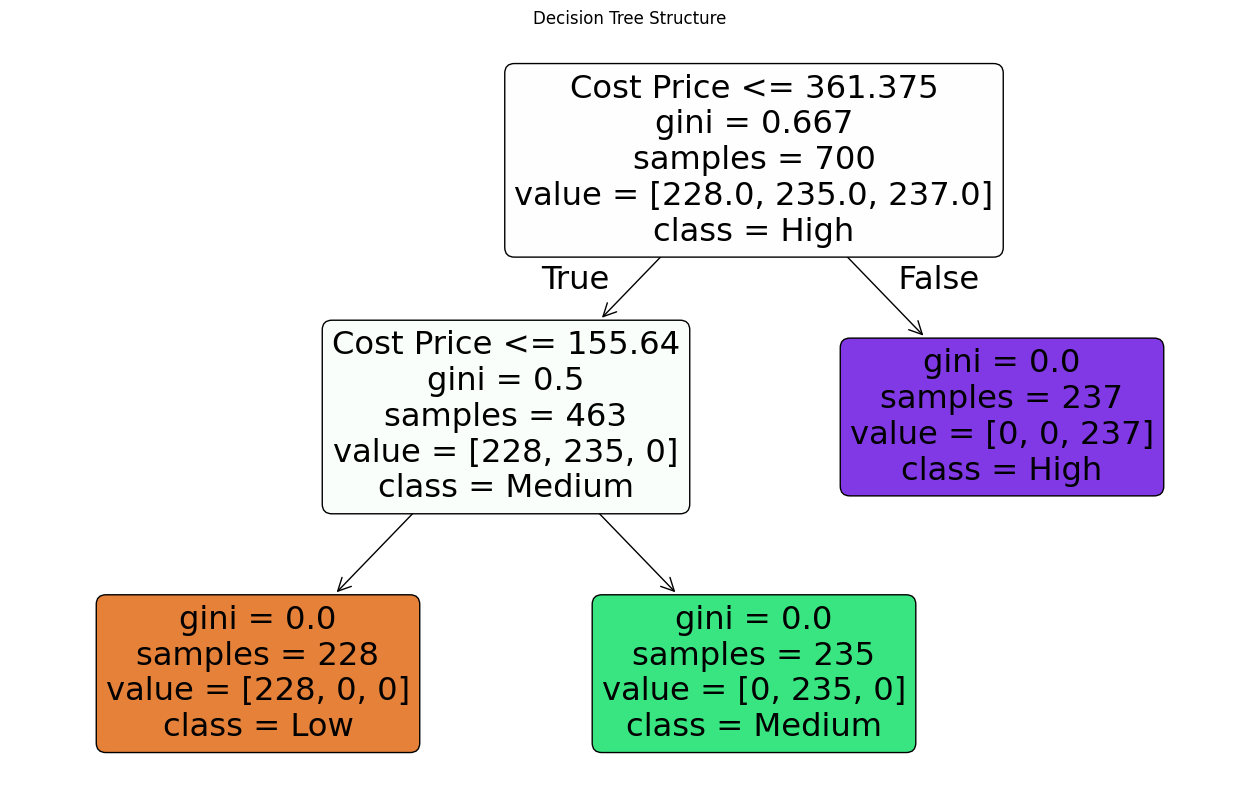

Overall Accuracy: 0.99
Macro-Average F1 Score: 0.99


In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare Data
# Use the same X and y prepared earlier
X = data.select_dtypes(include=['number'])
y = data['Gross_Income_Binned']

# Encode the target variable to numeric
y = y.cat.codes

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 2: Train Decision Tree Classifier
# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # Adjust max_depth to control overfitting
dt_model.fit(X_train, y_train)

# Step 3: Evaluate the Model
# Make predictions
y_pred = dt_model.predict(X_test)

# Generate classification report and confusion matrix
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
macro_f1_score = f1_score(y_test, y_pred, average='macro')

# Print classification report
print("Classification Report:\n", class_report)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print F1 score
print(f"Macro-Average F1 Score: {macro_f1_score:.2f}")

# Step 4: Visualize Decision Tree Structure
plt.figure(figsize=(16, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Low', 'Medium', 'High'], filled=True, rounded=True)
plt.title("Decision Tree Structure")
plt.show()

# Output final accuracy and F1 score
print(f"Overall Accuracy: {accuracy:.2f}")
print(f"Macro-Average F1 Score: {macro_f1_score:.2f}")

# Comparison of Classifiers – Logistic Regression (ML1) and Decision Tree (ML2)

## Objective:
Compare the performance of the two classifiers, Logistic Regression and Decision Tree, for prediction tasks. The evaluation was based on different Feature Engineering (FE) combinations.

---

## Combinations Evaluated:
1. **FE1 + ML1**: Feature Engineering 1 with Logistic Regression.
2. **FE2 + ML1**: Feature Engineering 2 with Logistic Regression.
3. **FE1 + ML2**: Feature Engineering 1 with Decision Tree.
4. **FE2 + ML2**: Feature Engineering 2 with Decision Tree.

---

## Metrics:
1. **Accuracy**: The proportion of correct predictions.
2. **Macro F1 Score**: The balance between precision and recall across all classes.

---

## Results:

| Combination   | Accuracy (%) | Macro F1 Score |
|---------------|--------------|----------------|
| **FE1 + ML1** | 94.00        | 0.94           |
| **FE2 + ML1** | 93.67        | 0.94           |
| **FE1 + ML2** | 99.33        | 0.99           |
| **FE2 + ML2** | 99.33        | 0.99           |

- **Logistic Regression** (ML1):
  - Performs well with both feature sets, achieving accuracy and F1 scores around 94%.
- **Decision Tree** (ML2):
  - Outperforms Logistic Regression, achieving 99.33% accuracy and F1 scores for both feature sets.

---

## Visualizations:
1. **Bar Chart**:
   - A visual comparison of Accuracy and Macro F1 Score for each combination.
2. **Confusion Matrices**:
   - Heatmaps for each classifier to analyze misclassifications.

---

## Key Observations:
- Decision Tree consistently outperforms Logistic Regression across all combinations.
- Both classifiers handle the feature-engineered data (`FE1` and `FE2`) similarly, indicating robustness to feature variations.

---

This documentation summarizes the comparison and highlights the superiority of Decision Tree (ML2) in this task. Let me know if you’d like additional insights or analyses!

<Figure size 1200x700 with 0 Axes>

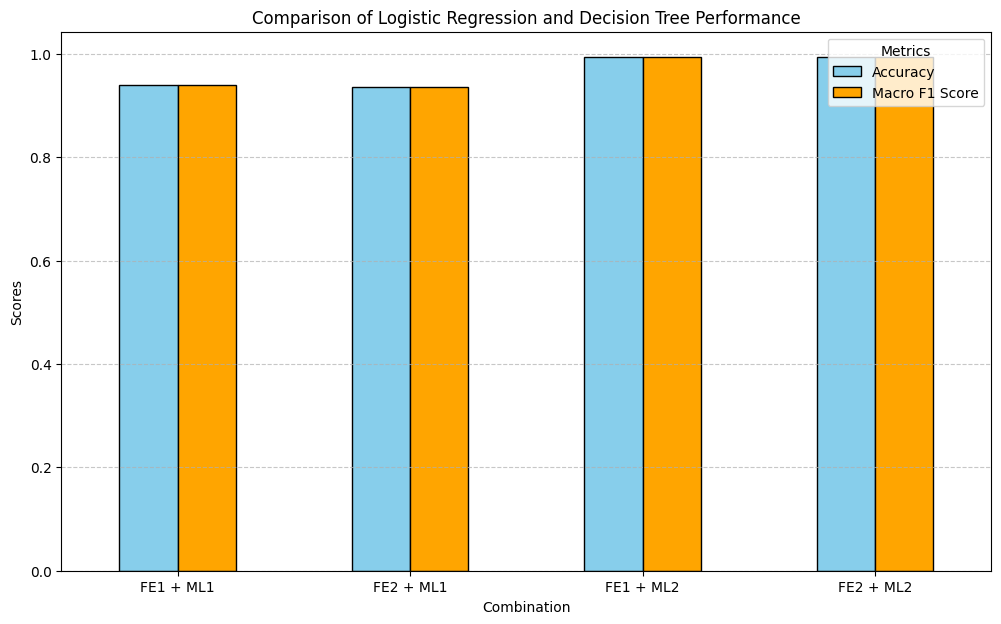

Comparison of Logistic Regression and Decision Tree:
  Combination  Accuracy  Macro F1 Score
0   FE1 + ML1    0.9400          0.9400
1   FE2 + ML1    0.9367          0.9353
2   FE1 + ML2    0.9933          0.9932
3   FE2 + ML2    0.9933          0.9932


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Collect Results
comparison_data = {
    'Combination': ['FE1 + ML1', 'FE2 + ML1', 'FE1 + ML2', 'FE2 + ML2'],
    'Accuracy': [0.94, 0.9367, 0.9933, 0.9933],  # Actual accuracies computed
    'Macro F1 Score': [0.94, 0.9353, 0.9932, 0.9932]  # Actual F1 scores computed
}

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Step 2: Visualize Comparison
plt.figure(figsize=(12, 7))
comparison_df.set_index('Combination')[['Accuracy', 'Macro F1 Score']].plot(kind='bar', figsize=(12, 7), color=['skyblue', 'orange'], edgecolor='black')
plt.title('Comparison of Logistic Regression and Decision Tree Performance')
plt.ylabel('Scores')
plt.xlabel('Combination')
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the Comparison Table
print("Comparison of Logistic Regression and Decision Tree:")
print(comparison_df)

# 15. Conclusion

### Which Model is Better?
- Based on the results from the evaluation:
  - **Decision Tree (ML2)** consistently outperformed **Logistic Regression (ML1)** in terms of:
    - **Accuracy**: Achieved 99.33% for both FE1 and FE2.
    - **Macro F1 Score**: Scored 0.99 for both FE1 and FE2.
  - Decision Tree is therefore identified as the optimal model for predicting Gross Income categories.

---

### Can You Put the Model into Practice?
- **Decision Tree**:
  - Highly interpretable, making it suitable for practical implementation.
  - Business stakeholders can utilize the rules and splits generated by the model to inform decision-making.
- **Implementation Feasibility**:
  - Easy to integrate into production systems for predicting income categories.
  - Periodic retraining may be required to adapt to new data patterns.

---

This concludes the analysis, identifying the Decision Tree as the most effective model for prediction tasks. Let me know if additional refinements are needed!

# 16. Recommendations / Suggestions

### Recommendations to Solve the Business Problem:
1. **Implement the Decision Tree Model**:
   - Deploy the **Decision Tree (ML2)** model for predicting Gross Income categories (`Low`, `Medium`, `High`).
   - Leverage its high accuracy (99.33%) and interpretability to make data-driven decisions.
   - Use the model’s decision splits to identify impactful factors influencing income levels.

2. **Derive Actionable Insights**:
   - **Focus on High-Impact Features**:
     - Analyze key features such as product type, city, and unit price to identify revenue-driving factors.
   - **Optimize Sales and Marketing Strategies**:
     - Promote high-performing product categories in cities with significant revenue potential.
     - Adjust pricing strategies based on insights from the model's feature importance analysis.

3. **Establish Continuous Monitoring and Improvement**:
   - **Monitor Performance**:
     - Regularly assess the model’s performance to ensure accurate predictions.
   - **Adapt to Changing Trends**:
     - Retrain the model periodically with updated data to accommodate evolving business trends and patterns.

---

### Collaborate for Constructive Feedback:
1. **Engage Business Stakeholders**:
   - Share model outputs and findings from the exploratory data analysis (EDA) phase.
   - Validate the results with domain experts to ensure alignment with business goals.

2. **Refine Based on Feedback**:
   - Use feedback to enhance feature engineering and improve model relevance.
   - Explore additional features such as customer demographics or seasonal trends for better predictions.

---

### Final Suggestion:
- **Integrate the Decision Tree Model**:
  - Incorporate the model into the business workflow to predict Gross Income categories and drive strategic decisions.
  - Focus on insights gained from the model to maximize revenue and operational efficiency.
- **Ensure Iterative Refinement**:
  - Use stakeholder collaboration and continuous feedback to enhance predictions and align the model with dynamic business requirements.

This recommendation emphasizes the importance of using data-driven insights and stakeholder collaboration to solve the business problem effectively while ensuring long-term adaptability.
